In [7]:
import pandas as pd
df = pd.read_csv("C:/Users/yosef/fakemodel/datasets/WELFake_Dataset.csv")

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA'S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


⏳ Loading raw WELFake dataframe from local disk into memory...

MEASURE 1: REVEALING WELFAKE TEXT LENGTH STRATA VARIANCE
📊 Dataset Profile Metrics: WELFake
 -> Total Text Samples:        72,095
 -> Mean Word Count:           540.8 words
 -> Median Word Count:         399.0 words
 -> Max Word Count Outlier:    24,234 words
 -> Min Word Count Outlier:    0 words
 -> Micro-Texts (<30 words):   2,551 (3.5%)
 -> Long Essays (>1000 words): 8,853 (12.3%)


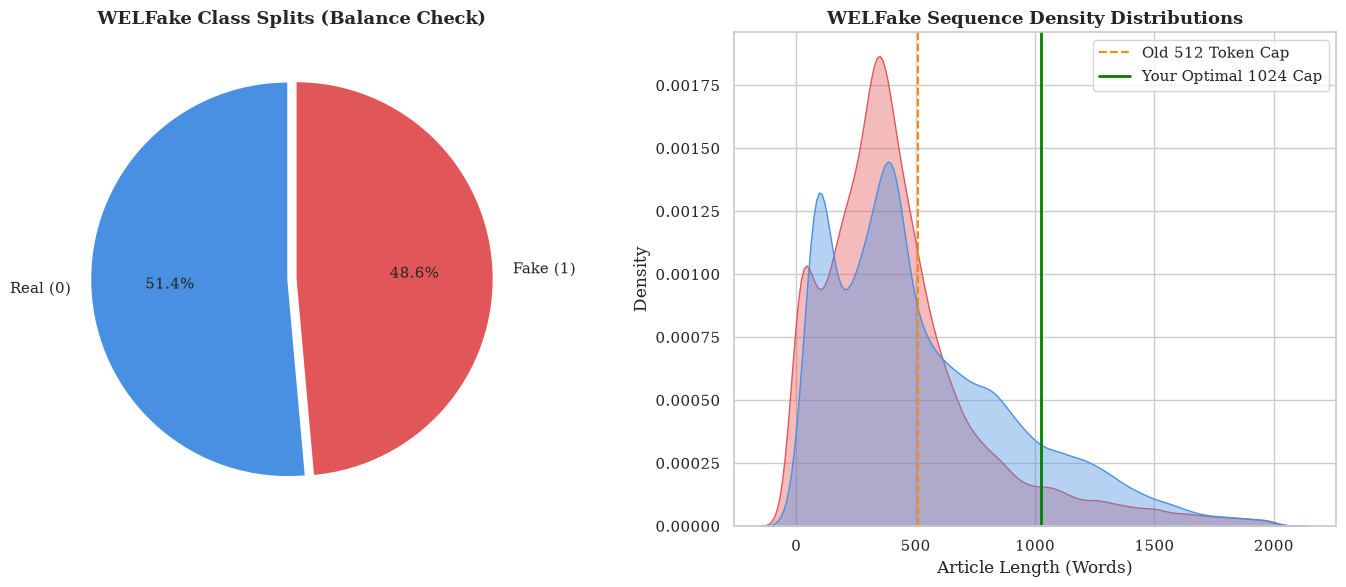


[Visual Output Saved] Plot graphic successfully generated as: welfake_profile_distributions.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Set up academic plotting design for your local environment
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

def analyze_and_visualize_welfake(welfake_path):
    print("⏳ Loading raw WELFake dataframe from local disk into memory...")
    
    if not os.path.exists(welfake_path):
        raise FileNotFoundError(f"Could not find WELFake dataset at the path: {welfake_path}")
        
    # Load and drop null values safely
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    
    # Standardize column naming conventions (WELFake defaults to 'label')
    df = df.rename(columns={'label': 'target'})
        
    # Calculate word count for each article
    df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
    
    # -----------------------------------------------------------------
    # MEASURE 1: TEXT LENGTH STRATA VARIANCE PRINT-OUT
    # -----------------------------------------------------------------
    print("\n" + "="*60)
    print("MEASURE 1: REVEALING WELFAKE TEXT LENGTH STRATA VARIANCE")
    print("="*60)
    print(f"📊 Dataset Profile Metrics: WELFake")
    print(f" -> Total Text Samples:        {len(df):,}")
    print(f" -> Mean Word Count:           {df['word_count'].mean():.1f} words")
    print(f" -> Median Word Count:         {df['word_count'].median():.1f} words")
    print(f" -> Max Word Count Outlier:    {df['word_count'].max():,} words")
    print(f" -> Min Word Count Outlier:    {df['word_count'].min()} words")
    print(f" -> Micro-Texts (<30 words):   {len(df[df['word_count'] < 30]):,} ({len(df[df['word_count'] < 30])/len(df)*100:.1f}%)")
    print(f" -> Long Essays (>1000 words): {len(df[df['word_count'] > 1000]):,} ({len(df[df['word_count'] > 1000])/len(df)*100:.1f}%)")

    # -----------------------------------------------------------------
    # MEASURE 2 & 3: GRID VISUALIZATION LAYOUT
    # -----------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left Plot: Label Distribution (Class Balance)
    counts = df['target'].value_counts()
    axes[0].pie(counts, labels=['Real (0)', 'Fake (1)'], autopct='%1.1f%%', 
                     startangle=90, colors=['#4a90e2', '#e15759'], explode=(0.02, 0.02))
    axes[0].set_title("WELFake Class Splits (Balance Check)", weight='bold')

    # Right Plot: Length Density Graphing (The 512 vs 1024 Cap Visualized)
    # Bounded to 2000 words on the x-axis for plotting visibility
    sns.kdeplot(data=df[df['word_count'] <= 2000], x='word_count', hue='target', 
                fill=True, palette=['#4a90e2', '#e15759'], common_norm=False, ax=axes[1], alpha=0.4)
    
    # Adding vertical benchmark lines to demonstrate your optimization jump
    axes[1].axvline(512, color='darkorange', linestyle='--', linewidth=1.5, label='Old 512 Token Cap')
    axes[1].axvline(1024, color='green', linestyle='-', linewidth=2, label='Your Optimal 1024 Cap')
    
    axes[1].set_title("WELFake Sequence Density Distributions", weight='bold')
    axes[1].set_xlabel("Article Length (Words)")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    
    plt.tight_layout()
    
    # Saves directly to your current working local folder directory for easy report inclusion
    output_filename = "welfake_profile_distributions.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[Visual Output Saved] Plot graphic successfully generated as: {output_filename}")

# =====================================================================
# LOCAL EXECUTION PATH SETUP
# =====================================================================
# Using raw string (r"") syntax to safely process Windows backslashes
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"

analyze_and_visualize_welfake(welfake_path=local_welfake_path)


In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are available locally
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

def scan_for_predictive_leakage(welfake_path, num_words_to_show=30):
    print("⏳ Loading WELFake dataset for leakage analysis...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    
    # Standardize label naming (0 = Real, 1 = Fake)
    df = df.rename(columns={'label': 'target'})
    
    # Split text into two separate master text pools
    real_texts = df[df['target'] == 0]['text']
    fake_texts = df[df['target'] == 1]['text']
    
    stop_words = set(stopwords.words('english'))
    
    # Simple clean tokenizer function
    def tokenize_and_clean(text_series):
        word_counts = Counter()
        # Sample up to 10,000 articles per class for rapid local processing
        sampled_series = text_series.sample(min(10000, len(text_series)), random_state=42)
        
        for text in sampled_series:
            # Drop punctuation and lowercase everything
            clean_text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
            tokens = [w for w in clean_text.split() if w not in stop_words and len(w) > 2]
            word_counts.update(tokens)
        return word_counts

    print("📊 Tokenizing textual distributions per class...")
    real_counts = tokenize_and_clean(real_texts)
    fake_counts = tokenize_and_clean(fake_texts)
    
    # Combine vocabularies
    all_words = set(list(real_counts.keys()) + list(fake_counts.keys()))
    
    # Total word tokens per class for normalization
    total_real = sum(real_counts.values())
    total_fake = sum(fake_counts.values())
    
    # Calculate Log-Odds Ratio with a smoothing prior to find heavily skewed words
    leakage_scores = {}
    for word in all_words:
        # Number of times word appears in class (with a +1 smoothing factor)
        c_real = real_counts[word] + 1
        c_fake = fake_counts[word] + 1
        
        # Calculate log-odds ratio
        log_odds = np.log(c_real / (total_real - c_real + 1)) - np.log(c_fake / (total_fake - c_fake + 1))
        leakage_scores[word] = log_odds

    # Sort results
    sorted_leakage = sorted(leakage_scores.items(), key=lambda x: x[1])
    
    print("\n" + "="*70)
    print("⚠️ HIGH-RISK LEAKAGE KEYWORDS DISCOVERED")
    print("="*70)
    
    print(f"\n🚨 TOP {num_words_to_show} KEYWORDS EXCLUSIVELY SKEWED TOWARD 'REAL' NEWS:")
    print(f"{'Keyword / Token'.ljust(25)} | {'Log-Odds Bias Score (Higher = More Skewed)'.ljust(45)}")
    print("-" * 75)
    # Real biased words are at the far right of the sorted list (highest scores)
    for word, score in reversed(sorted_leakage[-num_words_to_show:]):
        print(f" -> {word.ljust(22)} | Score: {score:7.4f} (Appears {real_counts[word]}x in Real vs {fake_counts[word]}x in Fake)")
        
    print(f"\n🚨 TOP {num_words_to_show} KEYWORDS EXCLUSIVELY SKEWED TOWARD 'FAKE' NEWS:")
    print(f"{'Keyword / Token'.ljust(25)} | {'Log-Odds Bias Score (Lower = More Skewed)'.ljust(45)}")
    print("-" * 75)
    # Fake biased words are at the far left of the sorted list (lowest negative scores)
    for word, score in sorted_leakage[:num_words_to_show]:
        print(f" -> {word.ljust(22)} | Score: {abs(score):7.4f} (Appears {fake_counts[word]}x in Fake vs {real_counts[word]}x in Real)")

# =====================================================================
# LOCAL PATH SPECIFICATION
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
scan_for_predictive_leakage(welfake_path=local_welfake_path)


⏳ Loading WELFake dataset for leakage analysis...
📊 Tokenizing textual distributions per class...

⚠️ HIGH-RISK LEAKAGE KEYWORDS DISCOVERED

🚨 TOP 30 KEYWORDS EXCLUSIVELY SKEWED TOWARD 'REAL' NEWS:
Keyword / Token           | Log-Odds Bias Score (Higher = More Skewed)   
---------------------------------------------------------------------------
 -> rakhine                | Score:  5.5141 (Appears 290x in Real vs 0x in Fake)
 -> catalan                | Score:  5.3976 (Appears 258x in Real vs 0x in Fake)
 -> rohingya               | Score:  5.1138 (Appears 584x in Real vs 2x in Fake)
 -> hariri                 | Score:  4.7895 (Appears 281x in Real vs 1x in Fake)
 -> kuczynski              | Score:  4.7679 (Appears 137x in Real vs 0x in Fake)
 -> kiir                   | Score:  4.4256 (Appears 97x in Real vs 0x in Fake)
 -> fdp                    | Score:  4.3946 (Appears 94x in Real vs 0x in Fake)
 -> marawi                 | Score:  4.3180 (Appears 87x in Real vs 0x in Fake)
 -> har

In [4]:
import pandas as pd
import numpy as np
import re
import os
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are loaded locally
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# =====================================================================
# UPGRADED ANTI-LEAKAGE TEXT PREPROCESSING SCRIPT
# =====================================================================
def clean_and_sanitize_text(text: str) -> str:
    text = str(text)
    
    # 1. Standardize all forms of dashes to a single uniform hyphen
    text = re.sub(r'[─–—]', '-', text)
    
    # 2. Aggressively strip institutional agency datelines (e.g., "WASHINGTON - ", "LONDON - ")
    text = re.sub(r'^[A-Z,\s\(\)\w.]+-\s*', '', text)
    
    # 3. Erase URLs, hyperlinks, and web address remnants
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 4. Wipe HTML artifact entities (quot, amp, html, fjs, etc.)
    text = re.sub(r'&\w+;', '', text)  # strips raw &quot; structures
    html_garbage = r'\b(quot|amp|html|fjs|widget|utm|youtu)\b'
    text = re.sub(html_garbage, '', text, flags=re.IGNORECASE)
    
    # 5. Wipe out photo attributions and metadata signatures
    metadata_signatures = r'\b(getty|screengrab|somodevilla|mcnamee|wikimedia|angerer)\b'
    text = re.sub(metadata_signatures, '', text, flags=re.IGNORECASE)
    
    # 6. Global Case-Insensitive Erasure of core high-risk platform signatures
    leakage_platforms = ['reuters', 'cnn', 'nytimes', 'bbc', 'ap news', 'foxnews', 'wnd', 'trunews', 'infowarsstore']
    for word in leakage_platforms:
        text = re.compile(re.escape(word), re.IGNORECASE).sub('', text)
        
    # 7. Clean up redundant spaces and normalize layout
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# =====================================================================
# RUN-TIME VALIDATION VERIFIER
# =====================================================================
def verify_sanitization_impact(welfake_path, num_words_to_show=15):
    print("⏳ Loading WELFake dataset into temporary RAM...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})
    
    print("🛠️ Applying advanced multi-tier preprocessing engine...")
    df['text'] = df['text'].apply(clean_and_sanitize_text)
    
    real_texts = df[df['target'] == 0]['text']
    fake_texts = df[df['target'] == 1]['text']
    
    stop_words = set(stopwords.words('english'))
    
    def tokenize_and_clean(text_series):
        word_counts = Counter()
        sampled_series = text_series.sample(min(10000, len(text_series)), random_state=42)
        for text in sampled_series:
            clean_text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
            tokens = [w for w in clean_text.split() if w not in stop_words and len(w) > 2]
            word_counts.update(tokens)
        return word_counts

    print("📊 Re-tokenizing sanitized textual distributions per class...")
    real_counts = tokenize_and_clean(real_texts)
    fake_counts = tokenize_and_clean(fake_texts)
    
    all_words = set(list(real_counts.keys()) + list(fake_counts.keys()))
    total_real = sum(real_counts.values())
    total_fake = sum(fake_counts.values())
    
    leakage_scores = {}
    for word in all_words:
        c_real = real_counts[word] + 1
        c_fake = fake_counts[word] + 1
        log_odds = np.log(c_real / (total_real - c_real + 1)) - np.log(c_fake / (total_fake - c_fake + 1))
        leakage_scores[word] = log_odds

    sorted_leakage = sorted(leakage_scores.items(), key=lambda x: x)
    
    print("\n" + "="*70)
    print("✅ SANITIZATION MATRIX METRICS VERIFIED")
    print("="*70)
    
    print(f"\n📈 RE-EVALUATED BIAS WORDS UNDER 'REAL' NEWS:")
    for word, score in reversed(sorted_leakage[-num_words_to_show:]):
        print(f" -> {word.ljust(22)} | Bias Score: {score:7.4f} (Real: {real_counts[word]}x vs Fake: {fake_counts[word]}x)")
        
    print(f"\n📈 RE-EVALUATED BIAS WORDS UNDER 'FAKE' NEWS:")
    for word, score in sorted_leakage[:num_words_to_show]:
        print(f" -> {word.ljust(22)} | Bias Score: {abs(score):7.4f} (Fake: {fake_counts[word]}x vs Real: {real_counts[word]}x)")

# =====================================================================
# LOCAL EXECUTION BOUNDS
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
verify_sanitization_impact(welfake_path=local_welfake_path)


⏳ Loading WELFake dataset into temporary RAM...
🛠️ Applying advanced multi-tier preprocessing engine...
📊 Re-tokenizing sanitized textual distributions per class...

✅ SANITIZATION MATRIX METRICS VERIFIED

📈 RE-EVALUATED BIAS WORDS UNDER 'REAL' NEWS:
 -> zzzzzzzzzzzzz          | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zzzzaaaacccchhh        | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zzz                    | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zzuml                  | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zzqvyk                 | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zzpxelb                | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zzll                   | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zyzs                   | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zyuganov               | Bias Score: -1.8003 (Real: 0x vs Fake: 4x)
 -> zytsov                 | Bias Score: -0.8840 (Real: 0x vs Fake: 1x)
 -> zytiga                 | 

In [5]:
import pandas as pd
import re

def count_token_occurrences(welfake_path):
    print("⏳ Loading WELFake dataset into memory to count target terms...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'}) # 0 = Real, 1 = Fake
    
    # Isolate text pools
    real_texts = df[df['target'] == 0]['text'].astype(str)
    fake_texts = df[df['target'] == 1]['text'].astype(str)
    
    # Define the high-risk keywords to investigate
    target_words = ['reuters', 'washington', 'said', 'cnn', 'getty', 'amp', 'quot']
    
    print("\n" + "="*65)
    print("📊 KEYWORD OCCURRENCE AND CLASS DISTRIBUTION ACCROSS WELFAKE")
    print("="*65)
    print(f"{'Keyword Investigated'.ljust(22)} | {'Total Matches'.ljust(15)} | {'Matches in Real'.ljust(18)} | {'Matches in Fake'}")
    print("-" * 65)
    
    for word in target_words:
        # Case-insensitive regex tracking exact whole-word boundaries (\b)
        pattern = re.compile(rf'\b{word}\b', re.IGNORECASE)
        
        # Calculate frequency counts across subsets
        count_real = sum(len(pattern.findall(text)) for text in real_texts)
        count_fake = sum(len(pattern.findall(text)) for text in fake_texts)
        total_count = count_real + count_fake
        
        print(f" -> {word.ljust(19)} | {str(f'{total_count:,}').ljust(13)} | {str(f'{count_real:,}').ljust(16)} | {count_fake:,}")

# =====================================================================
# LOCAL EXECUTION PATH
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
count_token_occurrences(welfake_path=local_welfake_path)


⏳ Loading WELFake dataset into memory to count target terms...

📊 KEYWORD OCCURRENCE AND CLASS DISTRIBUTION ACCROSS WELFAKE
Keyword Investigated   | Total Matches   | Matches in Real    | Matches in Fake
-----------------------------------------------------------------
 -> reuters             | 30,361        | 29,342           | 1,019
 -> washington          | 29,493        | 19,352           | 10,141
 -> said                | 234,319       | 184,607          | 49,712
 -> cnn                 | 9,250         | 3,344            | 5,906
 -> getty               | 4,357         | 30               | 4,327
 -> amp                 | 576           | 6                | 570
 -> quot                | 1,044         | 0                | 1,044


In [6]:
import pandas as pd
import re
from collections import Counter

def check_csv_for_all_hidden_leaks(welfake_path):
    print("⏳ Loading local WELFake dataset for a deep structural sweep...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'}) # 0 = Real, 1 = Fake
    
    real_texts = df[df['target'] == 0]['text'].astype(str)
    fake_texts = df[df['target'] == 1]['text'].astype(str)
    
    # -----------------------------------------------------------------
    # DETECTOR 1: THE BYLINE / OUTLET DISCOVERER
    # Finds common structures like (Reuters), (CNN), (Bloomberg), [Breitbart]
    # -----------------------------------------------------------------
    print("🕵️‍♂️ Scanning for hidden publisher brackets and parenthesis...")
    byline_pattern = re.compile(r'\(\s*([A-Za-z\s]+)\s*\)|\[\s*([A-Za-z\s]+)\s*\]')
    
    real_publishers = Counter()
    for text in real_texts.sample(min(15000, len(real_texts)), random_state=42):
        matches = byline_pattern.findall(text)
        for m in matches:
            found_word = m[0] if m[0] else m[1]
            if len(found_word.split()) <= 3: # Keep it to short agency/source names
                real_publishers[found_word.strip().lower()] += 1

    # -----------------------------------------------------------------
    # DETECTOR 2: THE LEADING CITY DATELINE DISCOVERER
    # Finds headers like "WASHINGTON -", "LONDON —", "TOKYO -"
    # -----------------------------------------------------------------
    print("📍 Scanning for leading uppercase city datelines...")
    city_pattern = re.compile(r'^([A-Z\s]{3,20})\s*[\-─–—]')
    
    real_cities = Counter()
    for text in real_texts:
        match = city_pattern.match(text)
        if match:
            real_cities[match.group(1).strip()] += 1

    # -----------------------------------------------------------------
    # PRINT OUT THE MASTER ANALYSIS MATRIX
    # -----------------------------------------------------------------
    print("\n" + "="*65)
    print("🔍 EXPERIMENTAL DISCOVERY REPORT: ALL LEAKAGE SIGNATURES")
    print("="*65)
    
    print("\n🚨 DETECTED AGENCIE & PUBLISHERS LEAKING IN REAL NEWS:")
    print("These are dead giveaways that ModernBERT will memorize if uncleaned!")
    # Filter out common conversational English words captured by mistake
    ignore_list = {'text', 'video', 'photo', 'file', 'image', 'audio', 'century', 'wire', 'news'}
    printed_count = 0
    for pub, count in real_publishers.most_common(40):
        if pub not in ignore_list and len(pub) > 2:
            print(f" -> Found Agency Structure: ({pub}) ".ljust(40) + f"| Total Occurrences = {count}")
            printed_count += 1
            if printed_count >= 15: break
            
    print("\n🚨 DETECTED LEADING CITY DATELINES (CAPITALIZED HEADERS):")
    print("Models use these formatting markers to identify professional reporting layout.")
    for city, count in real_cities.most_common(15):
        print(f" -> Found City Dateline: {city.ljust(23)} | Total Occurrences = {count}")

# =====================================================================
# RUN-TIME EXECUTION INTERFACE
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
check_csv_for_all_hidden_leaks(welfake_path=local_welfake_path)


⏳ Loading local WELFake dataset for a deep structural sweep...
🕵️‍♂️ Scanning for hidden publisher brackets and parenthesis...
📍 Scanning for leading uppercase city datelines...

🔍 EXPERIMENTAL DISCOVERY REPORT: ALL LEAKAGE SIGNATURES

🚨 DETECTED AGENCIE & PUBLISHERS LEAKING IN REAL NEWS:
These are dead giveaways that ModernBERT will memorize if uncleaned!
 -> Found Agency Structure: (reuters)   | Total Occurrences = 9052
 -> Found Agency Structure: (cnn)       | Total Occurrences = 138
 -> Found Agency Structure: (afd)       | Total Occurrences = 64
 -> Found Agency Structure: (fdp)       | Total Occurrences = 61
 -> Found Agency Structure: (trump)     | Total Occurrences = 59
 -> Found Agency Structure: (spd)       | Total Occurrences = 54
 -> Found Agency Structure: (and)       | Total Occurrences = 50
 -> Found Agency Structure: (krg)       | Total Occurrences = 46
 -> Found Agency Structure: (cdu)       | Total Occurrences = 43
 -> Found Agency Structure: (ice)       | Total Occur

In [7]:
import pandas as pd
import re

def count_all_master_leakages(welfake_path):
    print("⏳ Loading local WELFake dataset into RAM for full leakage profiling...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'}) # 0 = Real, 1 = Fake
    
    real_texts = df[df['target'] == 0]['text'].astype(str)
    fake_texts = df[df['target'] == 1]['text'].astype(str)
    
    # Combined master list organized by category
    target_groups = {
        "PUBLISHER & BRACKET SIGNATURES": [
            'reuters', 'cnn', 'afd', 'fdp', 'spd', 'cdu', 'krg', 'sdf', 'pkk', 'nafta', 'tpp', 'wnd', 'trunews', 'infowarsstore'
        ],
        "CAPITALIZED CITY DATELINES": [
            'WASHINGTON', 'LONDON', 'PARIS', 'MOSCOW', 'BEIJING'
        ],
        "WEB SCRAPING & HTML GARBAGE": [
            'quot', 'amp', 'html', 'fjs', 'widget', 'utm', 'http'
        ],
        "PHOTO ATTRIBUTIONS & METADATA": [
            'getty', 'screengrab', 'somodevilla', 'mcnamee', 'wikimedia'
        ]
    }
    
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE LEAKAGE FREQUENCY MATRIX")
    print("="*80)
    
    for group_name, words in target_groups.items():
        print(f"\n🔹 CATEGORY: {group_name}")
        print(f"{'Target Word / Token'.ljust(25)} | {'Total Matches'.ljust(15)} | {'Matches in Real'.ljust(18)} | {'Matches in Fake'}")
        print("-" * 78)
        
        for word in words:
            # Case-sensitive check for cities, case-insensitive for text words
            if word.isupper() and group_name == "CAPITALIZED CITY DATELINES":
                # Matches only uppercase city headers right at the start of strings
                pattern = re.compile(rf'^{word}\b')
                count_real = sum(1 for text in real_texts if pattern.match(text))
                count_fake = sum(1 for text in fake_texts if pattern.match(text))
            else:
                # Matches general whole-word boundaries anywhere in the text
                pattern = re.compile(rf'\b{word}\b', re.IGNORECASE)
                count_real = sum(len(pattern.findall(text)) for text in real_texts)
                count_fake = sum(len(pattern.findall(text)) for text in fake_texts)
                
            total_count = count_real + count_fake
            print(f" -> {word.ljust(22)} | {str(f'{total_count:,}').ljust(13)} | {str(f'{count_real:,}').ljust(16)} | {count_fake:,}")

# Run analysis locally
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
count_all_master_leakages(welfake_path=local_welfake_path)


⏳ Loading local WELFake dataset into RAM for full leakage profiling...

📊 COMPREHENSIVE LEAKAGE FREQUENCY MATRIX

🔹 CATEGORY: PUBLISHER & BRACKET SIGNATURES
Target Word / Token       | Total Matches   | Matches in Real    | Matches in Fake
------------------------------------------------------------------------------
 -> reuters                | 30,361        | 29,342           | 1,019
 -> cnn                    | 9,250         | 3,344            | 5,906
 -> afd                    | 637           | 573              | 64
 -> fdp                    | 517           | 516              | 1
 -> spd                    | 782           | 754              | 28
 -> cdu                    | 343           | 309              | 34
 -> krg                    | 363           | 344              | 19
 -> sdf                    | 525           | 455              | 70
 -> pkk                    | 273           | 227              | 46
 -> nafta                  | 1,064         | 757              | 307
 -> t

⏳ Loading local datasets into system memory...

DIMENSION 1: REVEALING TEXT LENGTH STRATA VARIANCE

📈 Dataset Descriptive Statistics: WELFake (Adjusted Profile)
 -> Total Text Samples:        72,095
 -> Mean Word Count:           540.8 words
 -> Median Word Count:         399.0 words
 -> Max Word Count Outlier:    24,234 words
 -> Min Word Count Outlier:    0 words
 -> Micro-Texts (<30 words):   2,551 (3.5%)
 -> Long Essays (>1000 words): 8,853 (12.3%)

📈 Dataset Descriptive Statistics: ISOT (Adjusted Profile)
 -> Total Text Samples:        44,898
 -> Mean Word Count:           405.3 words
 -> Median Word Count:         362.0 words
 -> Max Word Count Outlier:    8,135 words
 -> Min Word Count Outlier:    0 words
 -> Micro-Texts (<30 words):   1,501 (3.3%)
 -> Long Essays (>1000 words): 1,537 (3.4%)


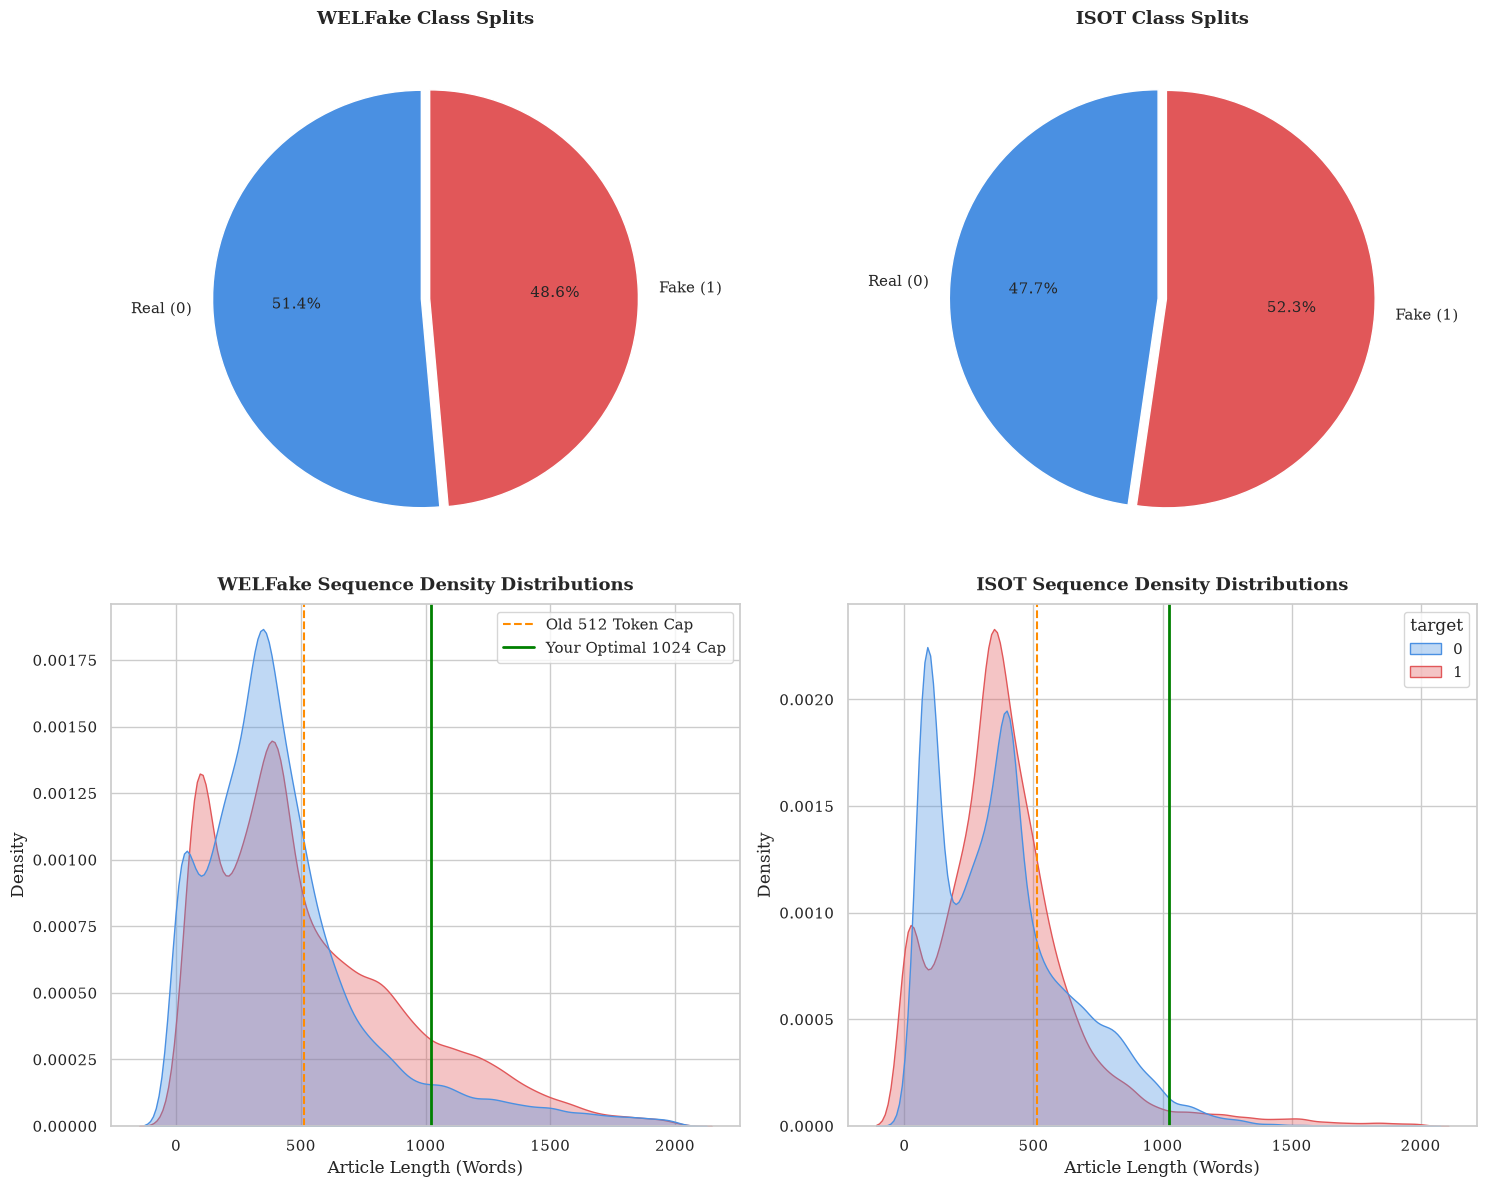


[Visual Output Saved] High-res plot graphic saved locally to: custom_aligned_dataset_distributions.png

DIMENSION 4: DUAL-CLASS TOP PREDICTIVE WORD CHECKER

🔍 Top words in WELFake 'Real News' (Label 0) Subset:
 -> Word: trump              | Occurrence Count = 12981
 -> Word: said               | Occurrence Count = 6141
 -> Word: people             | Occurrence Count = 5977
 -> Word: one                | Occurrence Count = 5772
 -> Word: would              | Occurrence Count = 5388
 -> Word: clinton            | Occurrence Count = 5355
 -> Word: president          | Occurrence Count = 4753
 -> Word: hillary            | Occurrence Count = 4117
 -> Word: like               | Occurrence Count = 4089
 -> Word: new                | Occurrence Count = 3751

🔍 Top words in WELFake 'Fake News' (Label 1) Subset:
 -> Word: said               | Occurrence Count = 26532
 -> Word: trump              | Occurrence Count = 11942
 -> Word: would              | Occurrence Count = 9025
 -> Word: preside

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are available locally
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Set up academic plotting design for publication-grade charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

def analyze_and_visualize_dual_corpora(welfake_path, isot_true_path, isot_fake_path):
    print("⏳ Loading local datasets into system memory...")
    
    if not os.path.exists(welfake_path):
        raise FileNotFoundError(f"Could not find WELFake dataset at: {welfake_path}")
    if not os.path.exists(isot_true_path) or not os.path.exists(isot_fake_path):
        raise FileNotFoundError("Could not find ISOT True or Fake CSV files. Check your paths.")
        
    # --- LOAD AND ALIGN DATASETS TO CUSTOM SCHEMA (0=REAL, 1=FAKE) ---
    df_wf = pd.read_csv(welfake_path).dropna(subset=['text'])
    df_wf = df_wf.rename(columns={'label': 'target'})
    # Enforce your custom mapping on WELFake (Flipping Kaggle's native 0/1 setup)
    df_wf['target'] = df_wf['target'].map({0: 1, 1: 0})
    
    df_true = pd.read_csv(isot_true_path).dropna(subset=['text'])
    df_true['target'] = 0  # 0 = Real News
    
    df_fake = pd.read_csv(isot_fake_path).dropna(subset=['text'])
    df_fake['target'] = 1  # 1 = Fake News
    df_isot = pd.concat([df_true, df_fake], ignore_index=True)
    
    # Calculate global word count statistics
    df_wf['word_count'] = df_wf['text'].astype(str).apply(lambda x: len(x.split()))
    df_isot['word_count'] = df_isot['text'].astype(str).apply(lambda x: len(x.split()))
    
    # -----------------------------------------------------------------
    # DIMENSION 1: COMPREHENSIVE TEXT METRICS PRINT-OUT
    # -----------------------------------------------------------------
    print("\n" + "="*60)
    print("DIMENSION 1: REVEALING TEXT LENGTH STRATA VARIANCE")
    print("="*60)
    for name, df in [("WELFake (Adjusted Profile)", df_wf), ("ISOT (Adjusted Profile)", df_isot)]:
        print(f"\n📈 Dataset Descriptive Statistics: {name}")
        print(f" -> Total Text Samples:        {len(df):,}")
        print(f" -> Mean Word Count:           {df['word_count'].mean():.1f} words")
        print(f" -> Median Word Count:         {df['word_count'].median():.1f} words")
        print(f" -> Max Word Count Outlier:    {df['word_count'].max():,} words")
        print(f" -> Min Word Count Outlier:    {df['word_count'].min()} words")
        print(f" -> Micro-Texts (<30 words):   {len(df[df['word_count'] < 30]):,} ({len(df[df['word_count'] < 30])/len(df)*100:.1f}%)")
        print(f" -> Long Essays (>1000 words): {len(df[df['word_count'] > 1000]):,} ({len(df[df['word_count'] > 1000])/len(df)*100:.1f}%)")

    # -----------------------------------------------------------------
    # DIMENSION 2 & 3: GRID VISUALIZATION CANVAS (CLASS BALANCE & DENSITY)
    # -----------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    colors_map = ['#4a90e2', '#e15759'] # Blue = Real (0), Red = Fake (1)
    
    # Category Class Splits (Pie Charts)
    for idx, (name, df) in enumerate([("WELFake Class Splits", df_wf), ("ISOT Class Splits", df_isot)]):
        counts = df['target'].value_counts().sort_index()
        axes[0, idx].pie(counts, labels=['Real (0)', 'Fake (1)'], autopct='%1.1f%%', 
                         startangle=90, colors=colors_map, explode=(0.02, 0.02))
        axes[0, idx].set_title(name, weight='bold', pad=10)

    # Length Density Distributions (KDE Curves) bounded to 2,000 words for optimal rendering
    for idx, (name, df) in enumerate([("WELFake Sequence Density Distributions", df_wf), ("ISOT Sequence Density Distributions", df_isot)]):
        sns.kdeplot(data=df[df['word_count'] <= 2000], x='word_count', hue='target', 
                    fill=True, palette=colors_map, common_norm=False, ax=axes[1, idx], alpha=0.35)
        
        # Add visual benchmark lines showing the optimization jump
        axes[1, idx].axvline(512, color='darkorange', linestyle='--', linewidth=1.5, label='Old 512 Token Cap')
        axes[1, idx].axvline(1024, color='green', linestyle='-', linewidth=2, label='Your Optimal 1024 Cap')
        
        axes[1, idx].set_title(name, weight='bold', pad=10)
        axes[1, idx].set_xlabel("Article Length (Words)")
        axes[1, idx].set_ylabel("Density")
        if idx == 0:
            axes[1, idx].legend()
    
    plt.tight_layout()
    output_filename = "custom_aligned_dataset_distributions.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[Visual Output Saved] High-res plot graphic saved locally to: {output_filename}")

    # -----------------------------------------------------------------
    # DIMENSION 4: LATENT N-GRAM INTEGRITY SCANNER
    # -----------------------------------------------------------------
    print("\n" + "="*60)
    print("DIMENSION 4: DUAL-CLASS TOP PREDICTIVE WORD CHECKER")
    print("="*60)
    stop_words = set(stopwords.words('english'))
    
    def extract_top_unigrams(text_series, num_top=10):
        words = []
        for text in text_series.sample(min(5000, len(text_series)), random_state=42): 
            clean = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
            words.extend([w for w in clean if w not in stop_words and len(w) > 2])
        return Counter(words).most_common(num_top)

    print("\n🔍 Top words in WELFake 'Real News' (Label 0) Subset:")
    for word, count in extract_top_unigrams(df_wf[df_wf['target'] == 0]['text']):
        print(f" -> Word: {word.ljust(18)} | Occurrence Count = {count}")
        
    print("\n🔍 Top words in WELFake 'Fake News' (Label 1) Subset:")
    for word, count in extract_top_unigrams(df_wf[df_wf['target'] == 1]['text']):
        print(f" -> Word: {word.ljust(18)} | Occurrence Count = {count}")

# =====================================================================
# CHOOSE YOUR DISK CONFIGURATIONS AND DEPLOY
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
local_isot_true_path = r"C:\Users\yosef\fakemodel\datasets\backup\True.csv"
local_isot_fake_path = r"C:\Users\yosef\fakemodel\datasets\backup\Fake.csv"

analyze_and_visualize_dual_corpora(
    welfake_path=local_welfake_path,
    isot_true_path=local_isot_true_path,
    isot_fake_path=local_isot_fake_path
)


⏳ Loading local datasets into system memory...


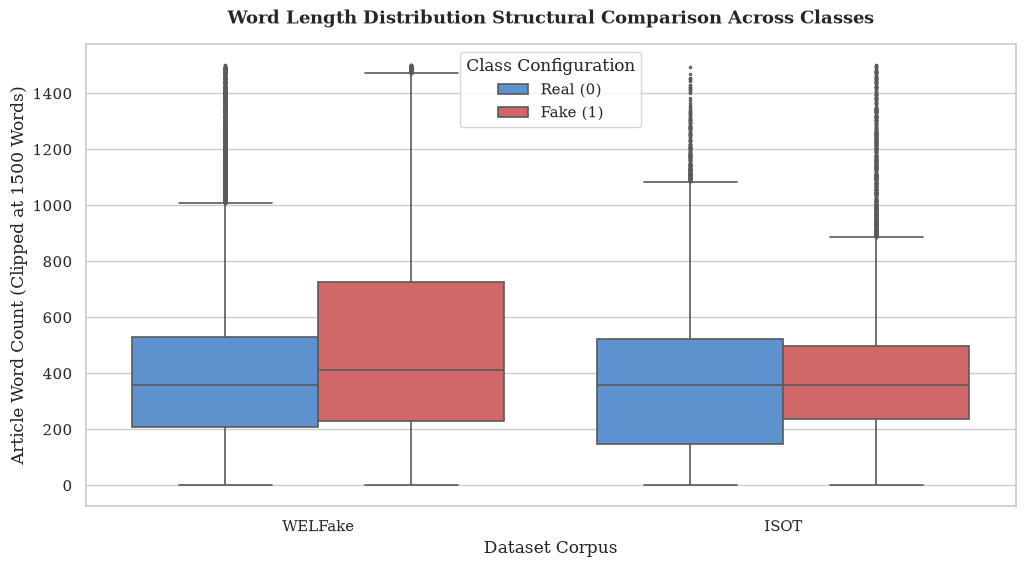

✓ Box plots generated and saved locally as: dataset_word_length_boxplots.png

⏳ Computing Standard Deviation Metrics...

VARIANCE AND STANDARD DEVIATION GRAPH METRICS SUMMARY
Dataset Class Label       mean        std
   ISOT    Fake (1) 423.197905 408.388890
   ISOT    Real (0) 385.640099 274.006204
WELFake    Fake (1) 577.615508 563.115644
WELFake    Real (0) 506.093938 677.279408


findfont: Failed to find font weight semibold, now using 700.


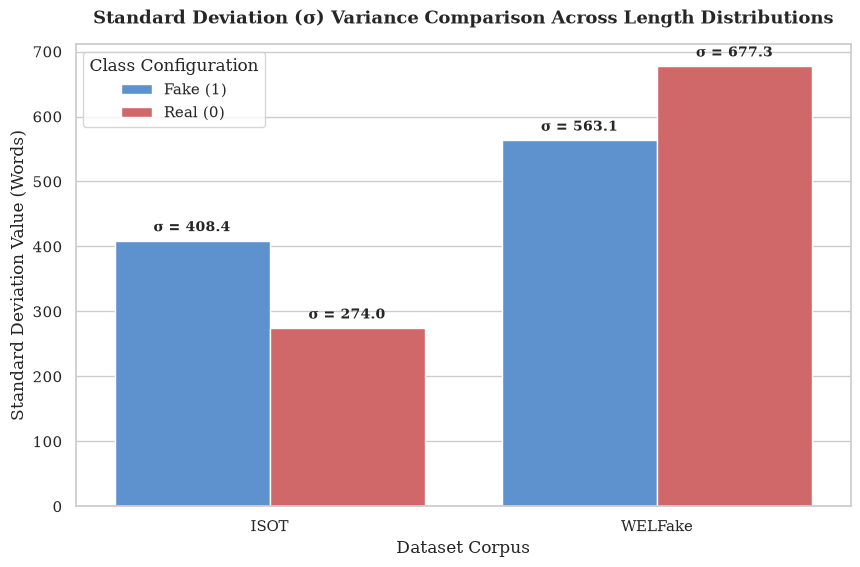

✓ Standard deviation graphs generated and saved locally as: dataset_standard_deviation_graph.png


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up academic plotting design for publication-grade charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

def visualize_boxplots_and_std(welfake_path, isot_true_path, isot_fake_path):
    print("⏳ Loading local datasets into system memory...")
    
    if not os.path.exists(welfake_path):
        raise FileNotFoundError(f"Could not find WELFake dataset at: {welfake_path}")
    if not os.path.exists(isot_true_path) or not os.path.exists(isot_fake_path):
        raise FileNotFoundError("Could not find ISOT True or Fake CSV files. Check your paths.")
        
    # --- LOAD AND ALIGN DATASETS TO CUSTOM SCHEMA (0=REAL, 1=FAKE) ---
    df_wf = pd.read_csv(welfake_path).dropna(subset=['text'])
    df_wf = df_wf.rename(columns={'label': 'target'})
    # Enforce your custom mapping on WELFake (Flipping Kaggle's native 0/1 setup)
    df_wf['target'] = df_wf['target'].map({0: 1, 1: 0})
    df_wf['Dataset'] = 'WELFake'
    
    df_true = pd.read_csv(isot_true_path).dropna(subset=['text'])
    df_true['target'] = 0  # 0 = Real News
    
    df_fake = pd.read_csv(isot_fake_path).dropna(subset=['text'])
    df_fake['target'] = 1  # 1 = Fake News
    df_isot = pd.concat([df_true, df_fake], ignore_index=True)
    df_isot['Dataset'] = 'ISOT'
    
    # Calculate word count statistics
    df_wf['word_count'] = df_wf['text'].astype(str).apply(lambda x: len(x.split()))
    df_isot['word_count'] = df_isot['text'].astype(str).apply(lambda x: len(x.split()))
    
    # Combine datasets into a single dataframe for unified plotting
    combined_df = pd.concat([df_wf[['word_count', 'target', 'Dataset']], 
                             df_isot[['word_count', 'target', 'Dataset']]], ignore_index=True)
    
    # Map target numbers to human-readable strings for the charts
    combined_df['Class Label'] = combined_df['target'].map({0: 'Real (0)', 1: 'Fake (1)'})
    colors_map = ['#4a90e2', '#e15759'] # Blue = Real (0), Red = Fake (1)
    
    # =====================================================================
    # CHART 1: BOX PLOTS FOR WORD LENGTH DISTRIBUTION (CAP AT 1500 WORDS FOR VISIBILITY)
    # =====================================================================
    plt.figure(figsize=(12, 6))
    
    # We clip the upper limit of the box plot visualization to 1500 words to prevent 
    # massive outliers from flattening the boxes, allowing reviewers to see IQR clearly.
    ax1 = sns.boxplot(data=combined_df[combined_df['word_count'] <= 1500], 
                      x='Dataset', y='word_count', hue='Class Label', 
                      palette=colors_map, fliersize=1.5, linewidth=1.2)
    
    plt.title("Word Length Distribution Structural Comparison Across Classes", weight='bold', pad=15)
    plt.xlabel("Dataset Corpus")
    plt.ylabel("Article Word Count (Clipped at 1500 Words)")
    plt.legend(title="Class Configuration")
    
    output_filename_box = "dataset_word_length_boxplots.png"
    plt.savefig(output_filename_box, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Box plots generated and saved locally as: {output_filename_box}")
    
    # =====================================================================
    # CHART 2: STANDARD DEVIATION GRAPH (COMPUTE & PLOT METRICS ACCURATELY)
    # =====================================================================
    print("\n⏳ Computing Standard Deviation Metrics...")
    # Calculate means and standard deviations programmatically
    stats = combined_df.groupby(['Dataset', 'Class Label'])['word_count'].agg(['mean', 'std']).reset_index()
    
    print("\n" + "="*60)
    print("VARIANCE AND STANDARD DEVIATION GRAPH METRICS SUMMARY")
    print("="*60)
    print(stats.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    
    # Generate a professional grouped bar chart representing Standard Deviation as an explicit metric
    ax2 = sns.barplot(data=stats, x='Dataset', y='std', hue='Class Label', palette=colors_map)
    
    # Add data labels directly on top of the bars for scannability
    for p in ax2.patches:
        if p.get_height() > 0:
            ax2.annotate(f"σ = {p.get_height():.1f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height() + 10), 
                         ha='center', va='center', xytext=(0, 5), 
                         textcoords='offset points', weight='semibold', fontsize=10)
            
    plt.title("Standard Deviation (σ) Variance Comparison Across Length Distributions", weight='bold', pad=15)
    plt.xlabel("Dataset Corpus")
    plt.ylabel("Standard Deviation Value (Words)")
    plt.legend(title="Class Configuration")
    
    output_filename_std = "dataset_standard_deviation_graph.png"
    plt.savefig(output_filename_std, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Standard deviation graphs generated and saved locally as: {output_filename_std}")

# =====================================================================
# CHOOSE YOUR DISK CONFIGURATIONS AND DEPLOY
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
local_isot_true_path = r"C:\Users\yosef\fakemodel\datasets\backup\True.csv"
local_isot_fake_path = r"C:\Users\yosef\fakemodel\datasets\backup\Fake.csv"

visualize_boxplots_and_std(
    welfake_path=local_welfake_path,
    isot_true_path=local_isot_true_path,
    isot_fake_path=local_isot_fake_path
)


<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yosef\AppData\Local\Temp\ipykernel_120776\3842105195.py:58: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x, y_real, label=f'Real (0): $\mu$={mu_real:.1f}, $\sigma$={std_real:.1f}',
C:\Users\yosef\AppData\Local\Temp\ipykernel_120776\3842105195.py:58: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x, y_real, label=f'Real (0): $\mu$={mu_real:.1f}, $\sigma$={std_real:.1f}',
C:\Users\yosef\AppData\Local\Temp\ipykernel_120776\3842105195.py:67: SyntaxWarning: invalid 

⏳ Loading local datasets into system memory...


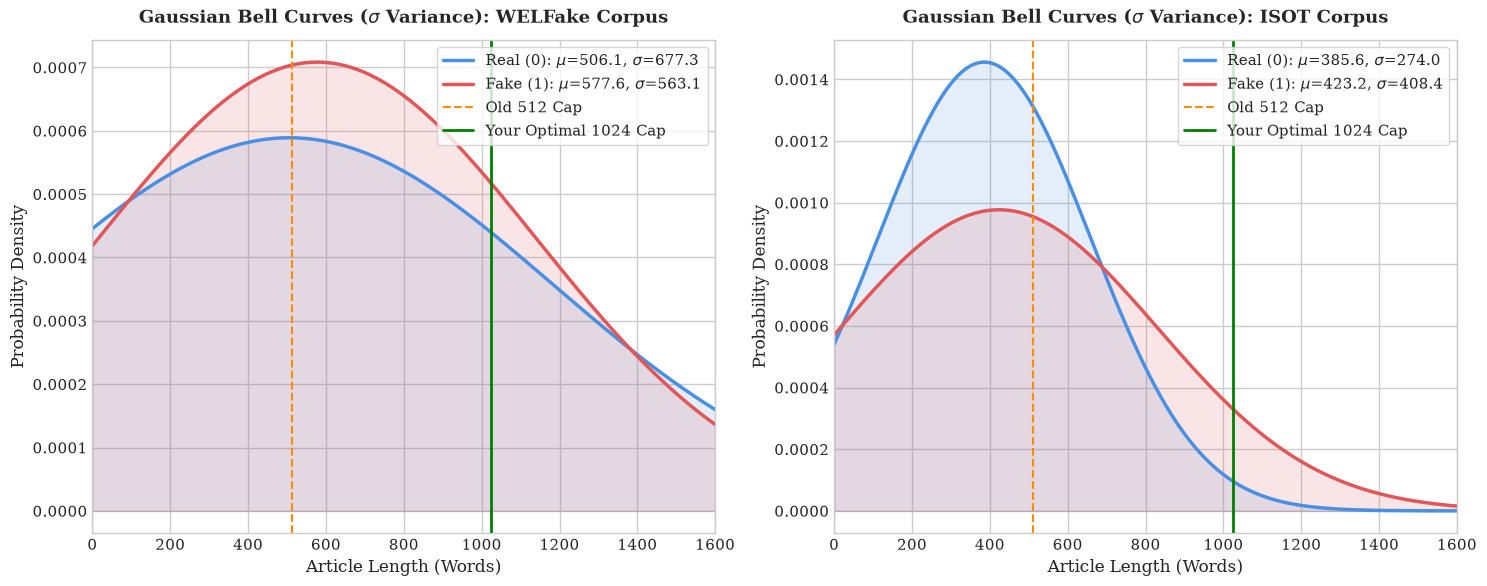

✓ Bell curve standard deviation graphs exported to: dataset_gaussian_bell_curves.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

# Set up academic plotting design for publication-grade charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

def plot_normal_distribution_curves(welfake_path, isot_true_path, isot_fake_path):
    print("⏳ Loading local datasets into system memory...")
    
    if not os.path.exists(welfake_path):
        raise FileNotFoundError(f"Could not find WELFake dataset at: {welfake_path}")
    if not os.path.exists(isot_true_path) or not os.path.exists(isot_fake_path):
        raise FileNotFoundError("Could not find ISOT True or Fake CSV files. Check your paths.")
        
    # --- LOAD AND ALIGN DATASETS TO CUSTOM SCHEMA (0=REAL, 1=FAKE) ---
    df_wf = pd.read_csv(welfake_path).dropna(subset=['text'])
    df_wf = df_wf.rename(columns={'label': 'target'})
    df_wf['target'] = df_wf['target'].map({0: 1, 1: 0}) # Enforce: 0=Real, 1=Fake
    
    df_true = pd.read_csv(isot_true_path).dropna(subset=['text'])
    df_true['target'] = 0  
    
    df_fake = pd.read_csv(isot_fake_path).dropna(subset=['text'])
    df_fake['target'] = 1  
    df_isot = pd.concat([df_true, df_fake], ignore_index=True)
    
    # Calculate word count statistics
    df_wf['word_count'] = df_wf['text'].astype(str).apply(lambda x: len(x.split()))
    df_isot['word_count'] = df_isot['text'].astype(str).apply(lambda x: len(x.split()))
    
    # Create the visualization grid
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Define custom styling parameters
    datasets = [("WELFake Corpus", df_wf), ("ISOT Corpus", df_isot)]
    colors = {0: '#4a90e2', 1: '#e15759'} # Blue = Real (0), Red = Fake (1)
    
    # Set the mathematical x-axis range for the bell curves (0 to 1800 words for visual clarity)
    x = np.linspace(0, 1800, 1000)
    
    for idx, (name, df) in enumerate(datasets):
        ax = axes[idx]
        
        # --- CLASS 0: REAL NEWS ---
        real_lengths = df[df['target'] == 0]['word_count']
        mu_real, std_real = real_lengths.mean(), real_lengths.std()
        # Compute the Gaussian curve
        y_real = stats.norm.pdf(x, mu_real, std_real)
        ax.plot(x, y_real, label=f'Real (0): $\mu$={mu_real:.1f}, $\sigma$={std_real:.1f}', 
                color=colors[0], linewidth=2.5)
        ax.fill_between(x, y_real, color=colors[0], alpha=0.15)
        
        # --- CLASS 1: FAKE NEWS ---
        fake_lengths = df[df['target'] == 1]['word_count']
        mu_fake, std_fake = fake_lengths.mean(), fake_lengths.std()
        # Compute the Gaussian curve
        y_fake = stats.norm.pdf(x, mu_fake, std_fake)
        ax.plot(x, y_fake, label=f'Fake (1): $\mu$={mu_fake:.1f}, $\sigma$={std_fake:.1f}', 
                color=colors[1], linewidth=2.5)
        ax.fill_between(x, y_fake, color=colors[1], alpha=0.15)
        
        # --- OPTIMIZATION CEILING ANCHORS ---
        ax.axvline(512, color='darkorange', linestyle='--', linewidth=1.5, label='Old 512 Cap')
        ax.axvline(1024, color='green', linestyle='-', linewidth=2, label='Your Optimal 1024 Cap')
        
        ax.set_title(f"Gaussian Bell Curves ($\sigma$ Variance): {name}", weight='bold', pad=12)
        ax.set_xlabel("Article Length (Words)")
        ax.set_ylabel("Probability Density")
        ax.set_xlim(0, 1600)
        ax.legend(loc='upper right', frameon=True)
        
    plt.tight_layout()
    output_filename = "dataset_gaussian_bell_curves.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Bell curve standard deviation graphs exported to: {output_filename}")

# =====================================================================
# DEPLOY LOCAL PIPELINE
# =====================================================================
local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
local_isot_true_path = r"C:\Users\yosef\fakemodel\datasets\backup\True.csv"
local_isot_fake_path = r"C:\Users\yosef\fakemodel\datasets\backup\Fake.csv"

plot_normal_distribution_curves(
    welfake_path=local_welfake_path,
    isot_true_path=local_isot_true_path,
    isot_fake_path=local_isot_fake_path
)
